# Benchmark, Inference, and FanchuanUnlearning

Load baseline checkpoints, preview predictions, run FanchuanUnlearning, and benchmark all model families.

In [1]:
from pathlib import Path

import json
import matplotlib.pyplot as plt

from data_utils import resolve_pipeline_paths

from notebook_workflows import (
    preview_checkpoint_predictions,
    results_to_dataframe,
    run_benchmark_notebook_workflow,
    run_fanchuan_unlearning_workflow,
)


In [2]:
# Centralized config
DATASET = "cifar10"
DEVICE = "auto"
NUM_BANK_SEEDS = 3
CHECKPOINT_DIR = Path("checkpoints")
BASELINE_TRAIN_FAMILY = "baseline_train"
BASELINE_RETRAIN_FAMILY = "baseline_retrain"
UNLEARN_FAMILY = "FanchuanUnlearning"
UNLEARN_PROFILE = DATASET
UNLEARN_REUSE_EXISTING = False
EVAL_BATCH_SIZE = 128 if DATASET == "cifar10" else 64
IMAGE_SIZE = 32 if DATASET == "cifar10" else 224
EFFICIENCY_RATIO = 0.20
UNLEARN_USE_WANDB = False
UNLEARN_WANDB_PROJECT = None
BENCHMARK_USE_WANDB = True
BENCHMARK_WANDB_PROJECT = "benchmark"

DATA_ROOT = None
TASK_MANIFEST = None
SAMPLES_CSV = None


In [3]:
_, resolved_task_manifest, _ = resolve_pipeline_paths(DATASET, SAMPLES_CSV, TASK_MANIFEST, DATA_ROOT)
TASK_ID = json.loads(resolved_task_manifest.read_text(encoding="utf-8"))["task_id"]
baseline_train_dir = CHECKPOINT_DIR / DATASET / TASK_ID / BASELINE_TRAIN_FAMILY
unlearn_outputs = run_fanchuan_unlearning_workflow(
    dataset=DATASET,
    base_family_dir=baseline_train_dir,
    output_family_name=UNLEARN_FAMILY,
    num_bank_seeds=NUM_BANK_SEEDS,
    profile=UNLEARN_PROFILE,
    checkpoint_dir=CHECKPOINT_DIR,
    data_root=DATA_ROOT,
    task_manifest=TASK_MANIFEST,
    samples_csv=SAMPLES_CSV,
    device_name=DEVICE,
    use_wandb=UNLEARN_USE_WANDB,
    wandb_project=UNLEARN_WANDB_PROJECT,
    image_size=IMAGE_SIZE,
    reuse_existing=UNLEARN_REUSE_EXISTING,
)

unlearn_outputs


{'family_name': 'FanchuanUnlearning',
 'seed_bank': [{'dataset': 'cifar10',
   'task_id': 'forget_mixed',
   'run_name': 'FanchuanUnlearning',
   'train_split': 'retain',
   'seed': 0,
   'epochs': 6,
   'batch_size': 64,
   'learning_rate': 0.0003,
   'momentum': 0.9,
   'weight_decay': 0.0,
   'class_weighting': 'none',
   'num_classes': 10,
   'label_to_index': {'0': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5,
    '6': 6,
    '7': 7,
    '8': 8,
    '9': 9},
   'class_names': ['airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'],
   'runtime_seconds': 102.77100519999976,
   'wall_clock_seconds': 107.32244989999981,
   'runtime_excludes_validation': True,
   'best_val_accuracy': 0.8408,
   'final_val_accuracy': 0.8408,
   'checkpoint_path': 'checkpoints\\cifar10\\forget_mixed\\FanchuanUnlearning\\seed_0.pth',
   'epochs_logged': [{'epoch': 0.0,
     'forget_loss': 2.3868063261343373,
     'ret

In [4]:
prediction_preview = preview_checkpoint_predictions(
    dataset=DATASET,
    checkpoint_path=unlearn_outputs["seed_bank"][0]["checkpoint_path"],
    loader_name="test",
    sample_count=5,
    batch_size=EVAL_BATCH_SIZE,
    image_size=IMAGE_SIZE,
    data_root=DATA_ROOT,
    task_manifest=TASK_MANIFEST,
    samples_csv=SAMPLES_CSV,
    device_name=DEVICE,
)

display(results_to_dataframe(prediction_preview))


,loader,target_index,target_label,predicted_index,predicted_label,predicted_probability,probabilities
0,test,3,cat,3,cat,0.990551,"[0.000217474575038068, 0.0004363740736152977, ..."
1,test,8,ship,8,ship,0.999908,"[7.932408152555581e-06, 7.971300510689616e-05,..."
2,test,8,ship,8,ship,0.960685,"[0.0066919466480612755, 0.025903604924678802, ..."
3,test,0,airplane,0,airplane,0.926464,"[0.9264643788337708, 0.003049353836104274, 0.0..."
4,test,6,frog,6,frog,0.891062,"[0.0007347316714003682, 0.004916313104331493, ..."


In [5]:
benchmark_outputs = run_benchmark_notebook_workflow(
    dataset=DATASET,
    checkpoint_dir=CHECKPOINT_DIR,
    baseline_train_family=BASELINE_TRAIN_FAMILY,
    baseline_retrain_family=BASELINE_RETRAIN_FAMILY,
    candidate_family_dirs={UNLEARN_FAMILY: unlearn_outputs["family_dir"]},
    efficiency_ratio=EFFICIENCY_RATIO,
    data_root=DATA_ROOT,
    task_manifest=TASK_MANIFEST,
    samples_csv=SAMPLES_CSV,
    device_name=DEVICE,
    batch_size=EVAL_BATCH_SIZE,
    image_size=IMAGE_SIZE,
    use_wandb=BENCHMARK_USE_WANDB,
    wandb_project=BENCHMARK_WANDB_PROJECT,
)

benchmark_outputs


Benchmarking Families:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluating Checkpoints:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluating Checkpoints:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluating Checkpoints:   0%|          | 0/3 [00:00<?, ?it/s]

Scoring Candidate Families:   0%|          | 0/2 [00:00<?, ?it/s]

Scoring Forget Examples (baseline_train):   0%|          | 0/4500 [00:00<?, ?it/s]

Scoring Forget Examples (FanchuanUnlearning):   0%|          | 0/4500 [00:00<?, ?it/s]

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\inzag\_netrc.
wandb: Currently logged in as: inmdev (inmdev-university-of-british-columbia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


comparison/FanchuanUnlearning/candidate_retain_accuracy,▁
comparison/FanchuanUnlearning/candidate_runtime_mean,▁
comparison/FanchuanUnlearning/candidate_test_accuracy,▁
comparison/FanchuanUnlearning/final_score,▁
comparison/FanchuanUnlearning/forgetting_quality,▁
comparison/FanchuanUnlearning/raw_final_score,▁
comparison/FanchuanUnlearning/reference_retain_accuracy,▁
comparison/FanchuanUnlearning/reference_runtime_mean,▁
comparison/FanchuanUnlearning/reference_test_accuracy,▁
comparison/baseline_train/candidate_retain_accuracy,▁
+19,...


{'dataset': 'cifar10',
 'reference_family': 'baseline_retrain',
 'family_summaries': {'baseline_train': {'retain_accuracy_mean': 1.0,
   'test_accuracy_mean': 0.8403,
   'runtime_seconds_mean': 607.5263268333341,
   'num_models': 3},
  'baseline_retrain': {'retain_accuracy_mean': 1.0,
   'test_accuracy_mean': 0.8262,
   'runtime_seconds_mean': 549.7587966000004,
   'num_models': 3},
  'FanchuanUnlearning': {'retain_accuracy_mean': 0.9998765432098765,
   'test_accuracy_mean': 0.8359333333333333,
   'runtime_seconds_mean': 102.51356176666634,
   'num_models': 3}},
 'comparisons_to_reference': {'baseline_train': {'forgetting_quality': 0.20844444444444443,
   'per_example_epsilons': [50.0,
    50.0,
    50.0,
    50.0,
    0.6931321804474443,
    50.0,
    50.0,
    0.6931321804474443,
    50.0,
    50.0,
    50.0,
    50.0,
    50.0,
    0.6931321804474443,
    0.6931321804474443,
    50.0,
    50.0,
    50.0,
    0.6931321804474443,
    50.0,
    50.0,
    0.6931321804474443,
    50.0,
 

In [6]:
family_df = results_to_dataframe(
    [
        {"family": family_name, **summary}
        for family_name, summary in benchmark_outputs["family_summaries"].items()
    ]
)
display(family_df)

comparison_df = results_to_dataframe(
    [
        {
            "family": family_name,
            "forgetting_quality": comparison["forgetting_quality"],
            "passed_efficiency_cutoff": comparison["passed_efficiency_cutoff"],
            "final_score": comparison["final_score"],
        }
        for family_name, comparison in benchmark_outputs["comparisons_to_reference"].items()
    ]
)
display(comparison_df)


,family,retain_accuracy_mean,test_accuracy_mean,runtime_seconds_mean,num_models
0,baseline_train,1.000000,0.840300,607.526327,3
1,baseline_retrain,1.000000,0.826200,549.758797,3
2,FanchuanUnlearning,0.999877,0.835933,102.513562,3


,family,forgetting_quality,passed_efficiency_cutoff,final_score
0,baseline_train,0.208444,False,NaN
1,FanchuanUnlearning,0.066000,True,0.066769


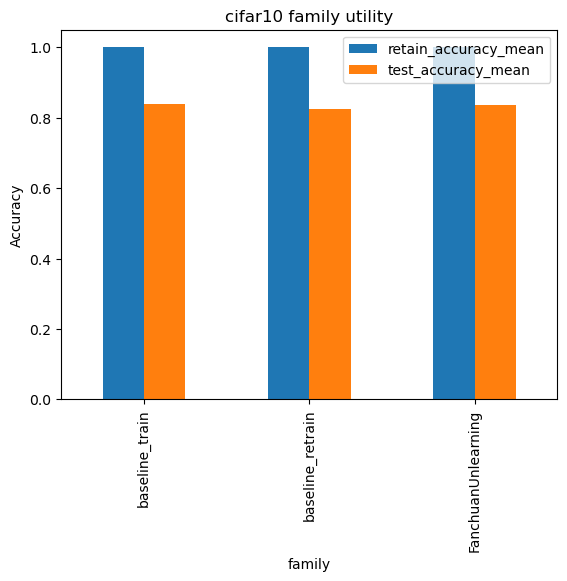

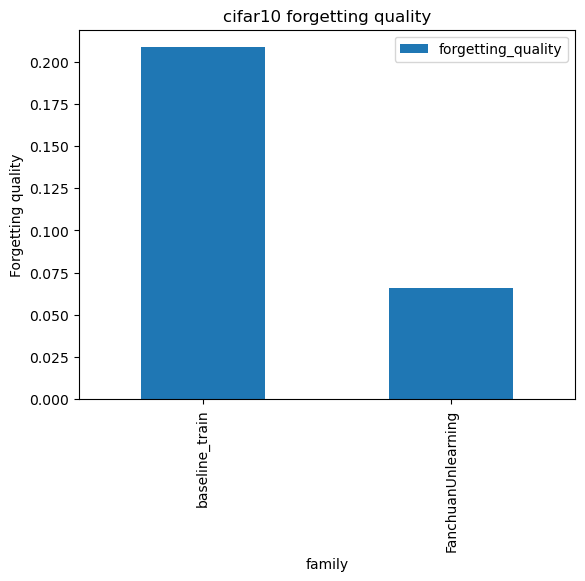

In [7]:
if hasattr(family_df, "plot"):
    ax = family_df.plot(x="family", y=["retain_accuracy_mean", "test_accuracy_mean"], kind="bar", title=f"{DATASET} family utility")
    ax.set_ylabel("Accuracy")
    plt.show()

if hasattr(comparison_df, "plot") and len(comparison_df) > 0:
    ax = comparison_df.plot(x="family", y="forgetting_quality", kind="bar", title=f"{DATASET} forgetting quality")
    ax.set_ylabel("Forgetting quality")
    plt.show()
